# Model Evaluation and Project Summary

This notebook summarizes and evaluates the main forecasting and sustainability results developed throughout the Energy Analytics Platform project.

The objective is to compare model performance across the different forecasting tasks and consolidate the key insights from:

- Electricity demand forecasting
- Solar generation forecasting
- Wind generation forecasting
- Renewable carbon impact analysis

This notebook does not introduce new models. Instead, it provides a high-level evaluation of the completed modelling workflow and identifies the final models selected for the project.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Helper functions

def standardize_results(df):
    if "R2" in df.columns:
        df.rename(columns={"R2": "R²"}, inplace=True)
    return df

def format_results_table(df):
    return df.style.format({
        "MAE": "{:.2f}",
        "RMSE": "{:.2f}",
        "R²": "{:.4f}"
    })

## Loading Saved Model Evaluation Results

To ensure consistency and reproducibility, model evaluation results are loaded directly from the saved project artifacts generated during the forecasting workflows.

This approach avoids hardcoding evaluation metrics and ensures that all subsequent analyses are based on the final saved model outputs.

In [14]:
import pandas as pd

demand_results = pd.read_csv(
    "../models/demand_forecasting/demand_model_comparison.csv"
)

solar_results = pd.read_csv(
    "../models/solar_generation/solar_model_comparison.csv"
)

wind_results = pd.read_csv(
    "../models/wind_generation/wind_model_comparison.csv"
)

demand_results = standardize_results(demand_results)
solar_results = standardize_results(solar_results)
wind_results = standardize_results(wind_results)

## Demand Forecasting Results

Electricity demand forecasting was the first predictive modelling task undertaken in this project.

The objective was to predict Germany's electricity demand using historical demand patterns, weather variables, and engineered temporal features. Multiple forecasting approaches were evaluated, ranging from a simple baseline model to advanced machine learning algorithms.

Model performance was assessed using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination (R²)

The results are presented below.

In [15]:
format_results_table(demand_results)

,Model,MAE,RMSE,R²
0,Baseline,1877.82,2461.99,0.9374
1,Linear Regression,1168.20,1490.44,0.9771
2,Random Forest,536.23,734.49,0.9944
3,XGBoost,534.47,709.96,0.9948
4,Reduced XGBoost,503.91,673.69,0.9953


## Interpretation of Demand Forecasting Results

The demand forecasting models achieved strong predictive performance across all evaluation metrics.

The baseline model already produced a relatively high R² score (0.9374), indicating that electricity demand exhibits strong temporal patterns and persistence. However, all machine learning models significantly improved forecasting accuracy compared with the baseline.

Linear Regression reduced both MAE and RMSE substantially, demonstrating that a large proportion of demand variability can be explained through linear relationships between demand, weather conditions, and temporal features.

Tree-based ensemble methods provided further improvements. Random Forest and XGBoost achieved R² values greater than 0.994, indicating excellent predictive performance.

The best-performing model was the Reduced XGBoost model, which achieved:

- MAE: 503.91
- RMSE: 673.69
- R²: 0.9953

The improvement obtained after feature selection suggests that removing less informative variables enhanced model generalization while reducing model complexity.

### Selected Demand Forecasting Model

**Reduced XGBoost**

The Reduced XGBoost model was selected as the final demand forecasting model due to its superior performance across all evaluation metrics.

## Demand Forecasting Model Comparison

To facilitate visual comparison, the forecasting models are compared using their MAE values. Lower MAE indicates better predictive accuracy.

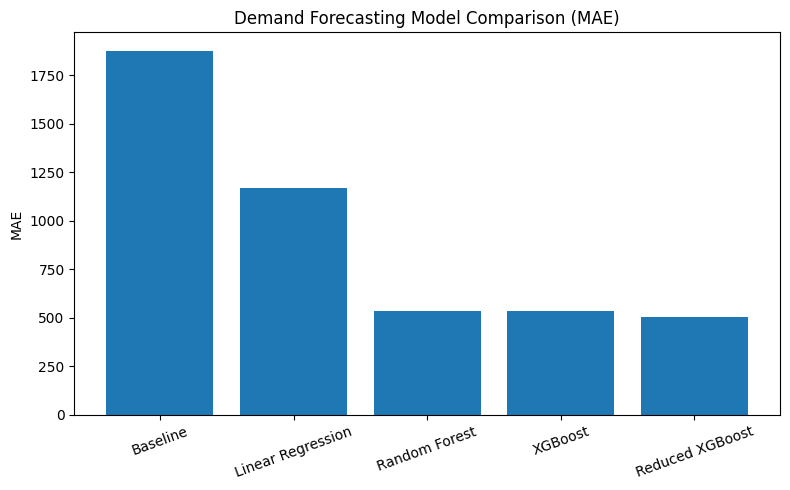

In [16]:
plt.figure(figsize=(8, 5))

plt.bar(
    demand_results["Model"],
    demand_results["MAE"]
)

plt.title("Demand Forecasting Model Comparison (MAE)")
plt.ylabel("MAE")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## Solar Generation Forecasting Results

The second forecasting task focused on predicting solar electricity generation in Germany.

Solar generation is highly dependent on meteorological conditions, seasonal patterns, and daylight availability. As a result, forecasting solar generation presents a more complex challenge than electricity demand forecasting.

Several machine learning models were evaluated, and additional feature engineering techniques were applied to improve forecasting performance. These enhancements included the incorporation of weather variables, cyclical time features, and temporal indicators designed to capture seasonal solar generation patterns.

The results are presented below.

In [17]:
format_results_table(solar_results)

,Model,MAE,RMSE,R²
0,Baseline,6072.52,8005.81,-0.0148
1,Linear Regression,3328.48,4107.97,0.7328
2,Random Forest,881.79,1711.90,0.9536
3,XGBoost,1002.72,1599.08,0.9595
4,Tuned XGBoost,953.51,1643.40,0.9572
5,Enhanced XGBoost,517.84,964.22,0.9804


## Interpretation of Solar Forecasting Results

The solar forecasting task demonstrated substantial improvements as more sophisticated machine learning techniques and engineered features were introduced.

The baseline model performed poorly, achieving a negative R² value (-0.0148), indicating that simple forecasting approaches were insufficient for capturing the variability of solar generation.

Linear Regression improved performance considerably, suggesting that weather and temporal variables contain meaningful information about solar generation. However, the nonlinear relationships present in solar generation data limited the effectiveness of purely linear models.

Tree-based ensemble methods produced major improvements. Random Forest and XGBoost both achieved R² values above 0.95, demonstrating strong predictive capability.

Hyperparameter tuning produced only marginal improvements to XGBoost performance. The most significant gains were achieved through feature engineering, which enhanced the model's ability to capture temporal and weather-driven patterns.

The Enhanced XGBoost model achieved the best overall performance:

- MAE: 517.84
- RMSE: 964.22
- R²: 0.9804

These results highlight the importance of domain-informed feature engineering in renewable energy forecasting applications.

### Selected Solar Forecasting Model

**Enhanced XGBoost**

The Enhanced XGBoost model was selected as the final solar forecasting model due to its superior predictive accuracy and robust performance across all evaluation metrics.

## Solar Forecasting Model Comparison

To facilitate visual comparison, the forecasting models are compared using their MAE values. Lower MAE indicates better predictive accuracy.

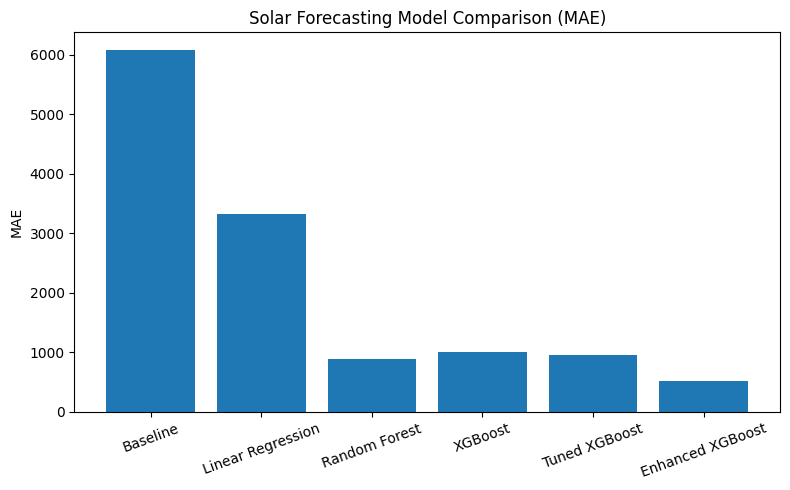

In [18]:
plt.figure(figsize=(8, 5))

plt.bar(
    solar_results["Model"],
    solar_results["MAE"]
)

plt.title("Solar Forecasting Model Comparison (MAE)")
plt.ylabel("MAE")
plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

## Wind Generation Forecasting Results

The third forecasting task focused on predicting wind electricity generation in Germany.

Wind generation is influenced by complex meteorological conditions and exhibits strong temporal dependencies. Unlike solar generation, wind generation often depends heavily on recent historical generation patterns, making lag-based feature engineering particularly important.

To improve forecasting performance, additional wind-specific lag features and rolling statistics were introduced. Multiple machine learning models were evaluated before and after feature engineering to assess their impact on predictive accuracy.

The results are presented below.

In [19]:
format_results_table(wind_results)

,Model,MAE,RMSE,R²
0,Baseline,8334.12,11049.17,-0.1096
1,Linear Regression,4050.68,5223.40,0.7520
2,Random Forest,4021.28,5238.75,0.7506
3,XGBoost,4364.69,5729.31,0.7017
4,Enhanced Linear Regression,753.89,1035.24,0.9903
5,Enhanced Random Forest,752.84,1040.98,0.9902
6,Enhanced XGBoost,786.76,1038.13,0.9902


## Interpretation of Wind Forecasting Results

The wind forecasting task produced some of the most striking results observed in this project.

The baseline model performed poorly, achieving a negative R² value (-0.1096), indicating that simple forecasting approaches were unable to capture the variability of wind generation.

Initial machine learning models showed moderate performance, with Linear Regression, Random Forest, and XGBoost achieving R² values between 0.70 and 0.75. These results suggested that the original feature set was insufficient for accurately representing wind generation dynamics.

A major breakthrough occurred after the introduction of wind-specific lag features and rolling statistics. These engineered features captured the strong temporal persistence inherent in wind generation data and dramatically improved model performance.

The enhanced models achieved R² values exceeding 0.99, representing a substantial improvement over the original feature set.

The best-performing model was the Enhanced Linear Regression model, which achieved:

- MAE: 753.89
- RMSE: 1035.24
- R²: 0.9903

The Enhanced Random Forest and Enhanced XGBoost models achieved nearly identical performance, indicating that the performance gains were driven primarily by feature engineering rather than model complexity.

A subsequent feature importance analysis revealed that the variable `wind_lag_1` was by far the most influential predictor. Removing this feature caused the XGBoost model R² to decline from approximately 0.99 to 0.83, confirming the critical importance of temporal dependencies in wind generation forecasting.

### Selected Wind Forecasting Model

**Enhanced XGBoost**

Although Enhanced Linear Regression achieved a marginally higher R² score, Enhanced XGBoost was selected as the final wind forecasting model to maintain consistency with the solar forecasting workflow and provide a robust nonlinear modelling framework for future deployment.

## Wind Forecasting Model Comparison

To facilitate visual comparison, the forecasting models are compared using their MAE values. Lower MAE indicates better predictive accuracy.

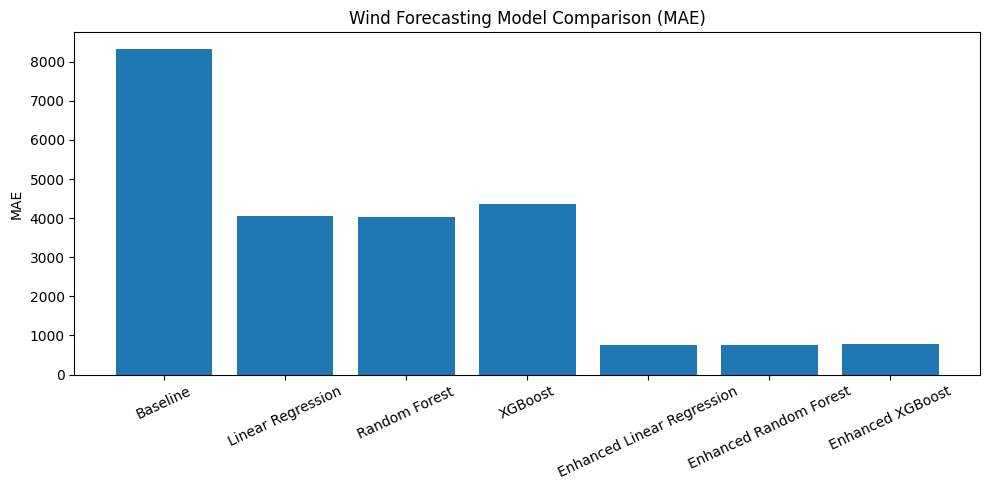

In [20]:
plt.figure(figsize=(10, 5))

plt.bar(
    wind_results["Model"],
    wind_results["MAE"]
)

plt.title("Wind Forecasting Model Comparison (MAE)")
plt.ylabel("MAE")
plt.xticks(rotation=25)

plt.tight_layout()

plt.show()

# Cross-Project Insights

The three forecasting tasks examined in this project—electricity demand forecasting, solar generation forecasting, and wind generation forecasting—revealed several important insights regarding model selection, feature engineering, and renewable energy prediction.

Comparing the results across tasks provides a broader understanding of the factors that influence forecasting performance within energy systems and highlights the importance of domain-specific feature engineering.

## Final Selected Models

The best-performing models from each forecasting task are summarized below.

In [21]:
final_models = pd.DataFrame({
    "Forecasting Task": [
        "Electricity Demand",
        "Solar Generation",
        "Wind Generation"
    ],
    "Selected Model": [
        "Reduced XGBoost",
        "Enhanced XGBoost",
        "Enhanced XGBoost"
    ],
    "MAE": [
        503.91,
        517.84,
        786.76
    ],
    "RMSE": [
        673.69,
        964.22,
        1038.13
    ],
    "R²": [
        0.9953,
        0.9804,
        0.9902
    ]
})

final_models.style.format({
    "MAE": "{:.2f}",
    "RMSE": "{:.2f}",
    "R²": "{:.4f}"
})

,Forecasting Task,Selected Model,MAE,RMSE,R²
0,Electricity Demand,Reduced XGBoost,503.91,673.69,0.9953
1,Solar Generation,Enhanced XGBoost,517.84,964.22,0.9804
2,Wind Generation,Enhanced XGBoost,786.76,1038.13,0.9902


## Key Lessons Learned

Several important lessons emerged from the forecasting workflows.

### 1. Feature Engineering Matters More Than Hyperparameter Tuning

Across both solar and wind forecasting tasks, the largest improvements were achieved through the introduction of meaningful engineered features rather than through model hyperparameter optimization.

Feature engineering consistently delivered larger performance gains than model tuning.

### 2. Different Energy Variables Require Different Features

Each forecasting task benefited from a distinct set of predictive features.

- Electricity demand forecasting benefited from temporal patterns and demand history.
- Solar forecasting benefited from weather variables and cyclical time features.
- Wind forecasting benefited most strongly from lag features and rolling statistics.

These findings demonstrate the importance of incorporating domain knowledge into feature design.

### 3. Tree-Based Models Performed Consistently Well

Random Forest and XGBoost models consistently achieved strong predictive performance across all forecasting tasks.

Their ability to capture nonlinear relationships and complex feature interactions made them well suited for energy forecasting applications.

### 4. Wind Generation Exhibits Strong Temporal Persistence

Feature importance analysis revealed that the variable `wind_lag_1` was the most influential predictor in the wind forecasting workflow.

Removing this feature caused forecasting performance to deteriorate substantially, confirming the strong temporal dependency present in wind generation data.

### 5. Renewable Energy Forecasting Supports Sustainability Assessment

The forecasting models developed in this project provide a foundation for estimating future renewable generation and associated environmental impacts.

These capabilities were demonstrated through the carbon impact analysis conducted in Notebook 09.

# Carbon Impact Summary

Beyond forecasting accuracy, an important objective of this project was to quantify the environmental benefits delivered by renewable electricity generation.

Using historical solar and wind generation data from Germany, avoided carbon emissions were estimated using an assumed grid emission factor of 475 kg CO₂/MWh.

In [22]:
carbon_summary = pd.DataFrame({
    "Metric": [
        "Solar CO₂ Avoided",
        "Wind CO₂ Avoided",
        "Total CO₂ Avoided"
    ],
    "Value (tonnes)": [
        109087910,
        276605175,
        385693084
    ]
})

carbon_summary.style.format({
    "Value (tonnes)": "{:,.0f}"
})

,Metric,Value (tonnes)
0,Solar CO₂ Avoided,"109,087,910"
1,Wind CO₂ Avoided,"276,605,175"
2,Total CO₂ Avoided,"385,693,084"


## Interpretation of Carbon Impact Results

The carbon impact analysis demonstrated the substantial environmental benefits delivered by renewable electricity generation in Germany between 2015 and 2020.

The analysis estimated that renewable generation avoided approximately 385.7 million tonnes of CO₂ emissions during the study period.

Wind generation contributed the majority of avoided emissions, accounting for approximately 71.7% of the total carbon impact. Solar generation contributed approximately 28.3%.

The results also revealed strong seasonal complementarity between solar and wind resources. Solar generation contributed most strongly during spring and summer months, while wind generation provided greater emissions reductions during autumn and winter.

These findings highlight the critical role of renewable electricity generation in supporting Germany's decarbonization objectives and demonstrate how forecasting tools can be linked directly to sustainability assessment.

# Overall Project Conclusions

This project successfully developed a comprehensive energy analytics workflow for forecasting electricity demand, solar generation, and wind generation in Germany while simultaneously quantifying the environmental benefits of renewable energy deployment.

The project demonstrated that:

- Machine learning methods can accurately forecast key energy system variables.
- Feature engineering is often more important than model complexity or hyperparameter tuning.
- Different energy variables require distinct forecasting strategies and domain-specific features.
- Renewable energy forecasting can be integrated with sustainability metrics to support energy transition analysis.
- Wind and solar resources exhibit complementary seasonal behaviour that supports year-round renewable electricity generation.

Across all forecasting tasks, XGBoost-based models consistently delivered strong predictive performance and were selected as the preferred modelling framework for deployment.

The final forecasting models achieved excellent predictive accuracy:

| Task | Selected Model | R² |
|--------|--------|--------|
| Demand Forecasting | Reduced XGBoost | 0.9953 |
| Solar Forecasting | Enhanced XGBoost | 0.9804 |
| Wind Forecasting | Enhanced XGBoost | 0.9902 |

The combination of forecasting and carbon impact analysis provides a strong foundation for data-driven decision making in energy systems and sustainability applications.

# Future Work

Several opportunities exist to extend the capabilities of this project.

## Forecasting Enhancements

- Multi-step renewable generation forecasting
- Day-ahead and week-ahead forecasting
- Probabilistic forecasting and uncertainty quantification
- Deep learning approaches (LSTM, GRU, Transformer models)

## Sustainability Analysis

- Future CO₂ avoidance estimation using forecasted renewable generation
- Dynamic grid carbon intensity modelling
- Renewable penetration analysis
- Energy transition scenario assessment

## Dashboard Development

The forecasting models and carbon impact metrics developed in this project will be integrated into an interactive dashboard to support visualization, exploration, and communication of energy system insights.

The dashboard will enable users to:

- Explore historical renewable generation trends
- View forecasting model performance
- Examine renewable energy forecasts
- Monitor carbon impact metrics
- Support energy transition decision making

# Saved Project Artifacts

Throughout the project, forecasting models, evaluation metrics, selected feature sets, and processed datasets were saved to ensure reproducibility and support future deployment.

The following artifacts were generated during the modelling workflows and will serve as inputs for dashboard development, future forecasting applications, and sustainability analyses.

This final check confirms that all key project outputs have been successfully stored and organized within the repository.

In [23]:
import os

print("Demand Forecasting Artifacts")
print(os.listdir("../models/demand_forecasting"))

print("\nSolar Forecasting Artifacts")
print(os.listdir("../models/solar_generation"))

print("\nWind Forecasting Artifacts")
print(os.listdir("../models/wind_generation"))

Demand Forecasting Artifacts
['demand_model_comparison.csv', 'demand_model_metrics.pkl', 'demand_reduced_xgboost_model.pkl', 'demand_selected_features.pkl']

Solar Forecasting Artifacts
['solar_feature_names.pkl', 'solar_model_comparison.csv', 'solar_model_metrics.pkl', 'solar_xgboost_enhanced.pkl']

Wind Forecasting Artifacts
['wind_feature_names.pkl', 'wind_model_comparison.csv', 'wind_model_metrics.pkl', 'wind_xgboost_enhanced.pkl']


# Project Workflow Summary

Data Collection
→ Data Cleaning
→ Exploratory Data Analysis
→ Feature Engineering
→ Demand Forecasting
→ Walk-Forward Validation
→ Solar Generation Forecasting
→ Wind Generation Forecasting
→ Carbon Impact Analysis
→ Model Evaluation
→ Dashboard Development

This workflow demonstrates a complete end-to-end energy analytics pipeline, combining data engineering, machine learning, renewable energy forecasting, and sustainability assessment.